In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt

In [2]:
from sklearn.impute import SimpleImputer
imputer= SimpleImputer(strategy='mean')
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
scaler = MinMaxScaler()
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear')

In [3]:
weather_df =pd.read_csv('weatherAUS.csv')
weather_df.dropna(subset=['MaxTemp','RainTomorrow','MinTemp','RainToday'],inplace=True)
year = pd.to_datetime(weather_df.Date).dt.year
train_df = weather_df[year<2015]
input_col = list(train_df.columns)[1:-1]
target_col ='RainTomorrow'
train_input = train_df[input_col].copy()
train_target = train_df[target_col].copy()
numeric_col = train_input.select_dtypes(include=np.number).columns.tolist()
categorical_col = train_input.select_dtypes('object').columns.tolist()

In [4]:
imputer.fit(weather_df[numeric_col])
train_input[numeric_col] = imputer.transform(train_input[numeric_col])

scaler.fit(train_input[numeric_col])
train_input[numeric_col]=scaler.transform(train_input[numeric_col])

encoder.fit(train_input[categorical_col])
encoded_col = list(encoder.get_feature_names_out(categorical_col))

In [5]:
train_input =pd.read_parquet('train_input.parquet')
val_input =pd.read_parquet('val_input.parquet')
test_input =pd.read_parquet('test_input.parquet')
train_target =pd.read_parquet('train_target.parquet')
val_target =pd.read_parquet('val_target.parquet')
test_target =pd.read_parquet('test_target.parquet')

In [6]:
model.fit(train_input[numeric_col + encoded_col],train_target)

C:\Users\taush\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(solver='liblinear')

In [7]:
model.coef_

array([[ 9.30806105e-01, -2.94915912e+00,  3.16391366e+00,
         6.41957834e-01, -1.64796054e+00,  6.82154655e+00,
        -6.98051388e-01, -1.45303292e+00,  3.29573960e-01,
         5.99816548e+00,  5.60338574e+00, -9.03420383e+00,
        -1.65363164e-01,  1.28376625e+00,  4.75512652e-01,
         2.01431079e+00,  5.95182273e-01, -5.60371723e-01,
         4.72499032e-01,  4.24402785e-03,  3.37599235e-01,
        -3.55575698e-01,  1.77137277e-01,  4.29677008e-01,
        -1.57583345e-02,  2.64458836e-02,  2.60996409e-01,
        -2.29350099e-02, -4.26160506e-02, -4.86887067e-01,
        -1.37524979e-01, -5.79314575e-01, -7.56150969e-01,
        -2.66373924e-01, -3.28180746e-01, -5.67919482e-01,
         7.93916941e-02,  9.70874231e-03,  6.65116245e-02,
        -9.50243894e-01, -4.55048058e-01,  8.28937643e-04,
        -4.67042633e-01, -4.67216793e-01, -7.94807009e-02,
         2.10731119e-01,  4.43028634e-01,  6.05471509e-01,
         4.26812913e-01, -2.82282928e-02,  2.39739332e-0

In [8]:
weight_df=pd.DataFrame({
    'feature':(numeric_col + encoded_col),
    'weight': model.coef_.tolist()[0]
})
weight_df


,feature,weight
0,MinTemp,0.930806
1,MaxTemp,-2.949159
2,Rainfall,3.163914
3,Evaporation,0.641958
4,Sunshine,-1.647961
...,...,...
113,WindDir3pm_WNW,-0.039991
114,WindDir3pm_WSW,-0.284794
115,WindDir3pm_nan,0.065308
116,RainToday_No,-1.556848


<Axes: xlabel='weight', ylabel='feature'>

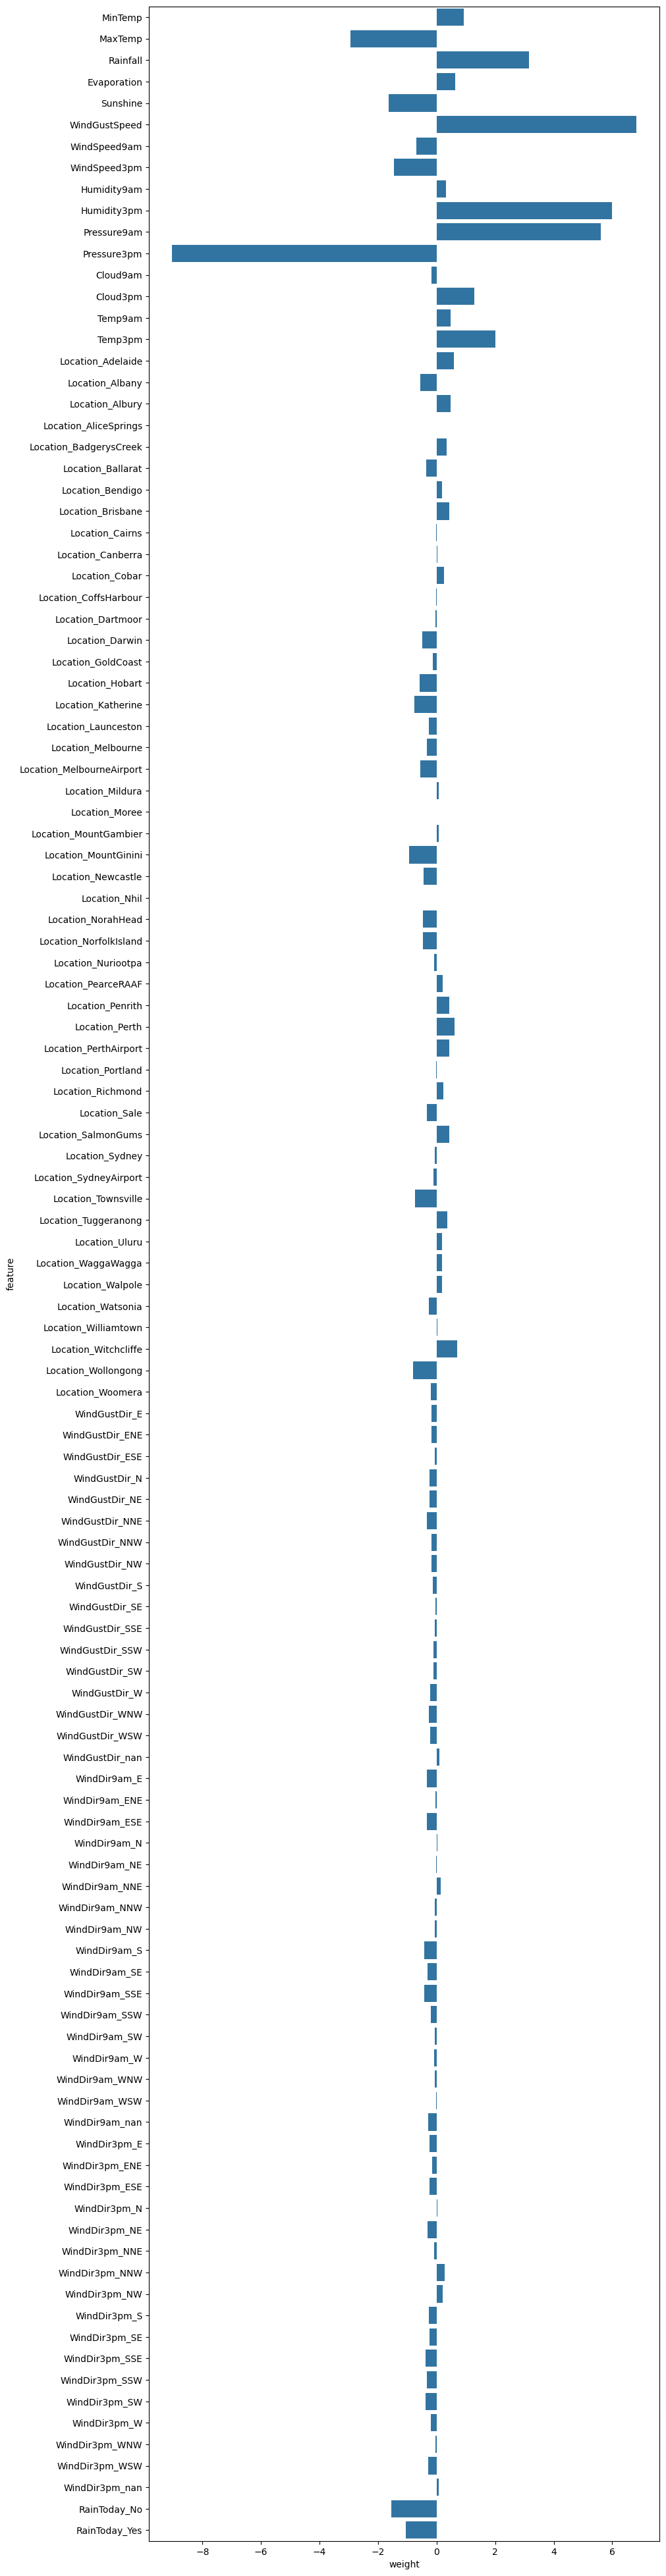

In [9]:
plt.figure(figsize=(10,50));
sns.barplot(data=weight_df,x='weight',y='feature')

<Axes: xlabel='weight', ylabel='feature'>

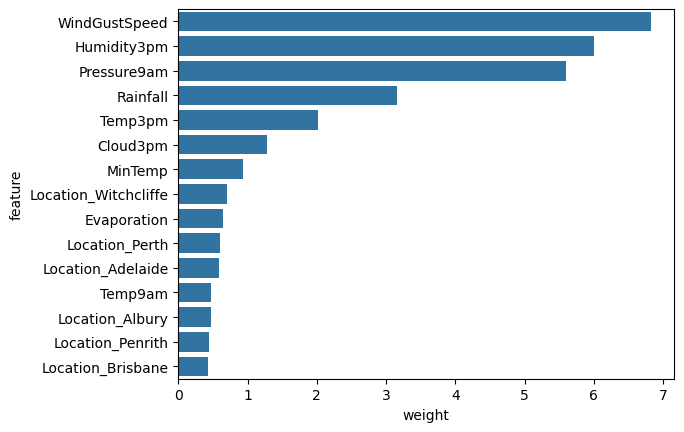

In [10]:
sns.barplot(data=weight_df.sort_values('weight',ascending=False).head(15),x='weight',y='feature')

In [11]:
x_train = train_input[numeric_col + encoded_col]
x_val = val_input[numeric_col + encoded_col]
x_test = test_input[numeric_col + encoded_col]

In [12]:
train_preds=model.predict(x_train)

In [13]:
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [14]:
train_target

,RainTomorrow
0,No
1,No
2,No
3,No
4,No
...,...
144548,No
144549,No
144550,No
144551,No


In [15]:
train_probs = model.predict_proba(x_train)
train_probs

array([[0.94401674, 0.05598326],
       [0.94072279, 0.05927721],
       [0.96137337, 0.03862663],
       ...,
       [0.98775605, 0.01224395],
       [0.98357026, 0.01642974],
       [0.87434857, 0.12565143]])

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy_score(train_preds,train_target)

0.851976011071813

In [17]:
confusion_matrix(train_target, train_preds, normalize ='true')

array([[0.94601651, 0.05398349],
       [0.47657438, 0.52342562]])

In [18]:
def predict_and_plot(input, target, name=''):
    preds = model.predict(input)
    accuracy = accuracy_score(preds,target)*100
    print(f'Accuracy : {accuracy:.2f}%')

    cf = confusion_matrix(target, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title(f'Confution Matrix {name}')
    return preds



Accuracy : 85.20%


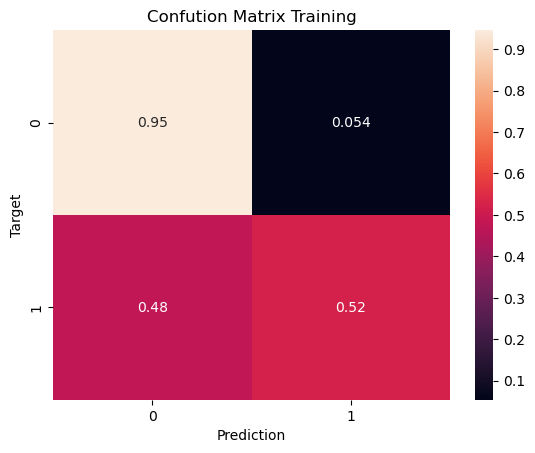

In [19]:
train_preds = predict_and_plot(x_train, train_target, 'Training')

Accuracy : 85.45%


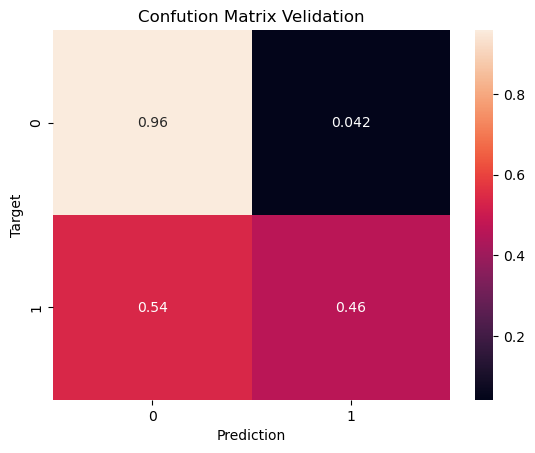

In [20]:
val_preds = predict_and_plot(x_val, val_target, 'Velidation')

Accuracy : 84.24%


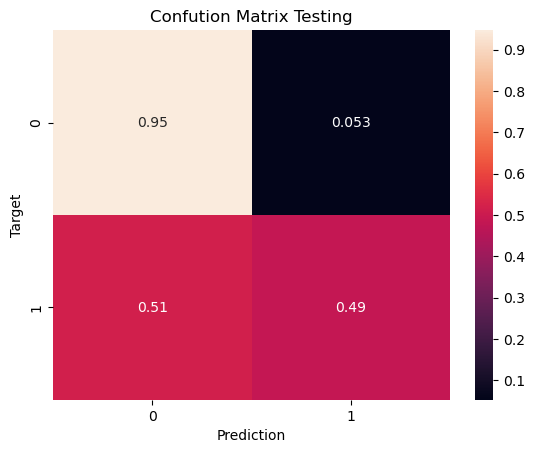

In [22]:
test_preds = predict_and_plot(x_test, test_target, 'Testing')

In [28]:
def random_guess(input):
    return np.random.choice(['No','Yes'], len(input))

In [25]:
def all_no(input):
    return np.full(len(input),'No')

In [39]:
dumb_model1 = random_guess(x_test)
dumb_model1

array(['Yes', 'No', 'No', ..., 'No', 'Yes', 'Yes'], dtype='<U3')

In [31]:
accuracy_score(test_target,random_guess(x_test))

0.5022340675707455

Accuracy : 49.76%


Text(0.5, 1.0, 'Confution Matrix Random Guess Dumb Model')

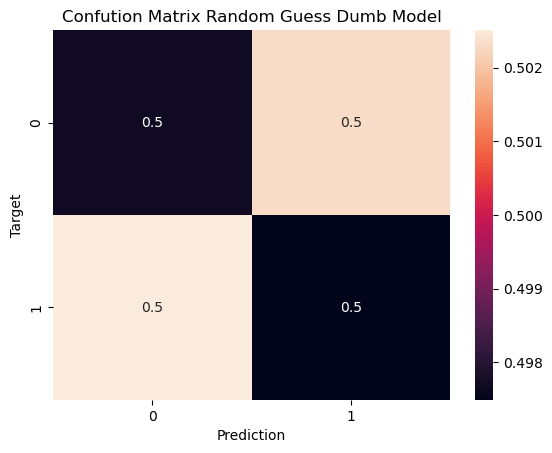

In [42]:

accuracy = accuracy_score(dumb_model1,test_target)*100
print(f'Accuracy : {accuracy:.2f}%')

cf = confusion_matrix(test_target, dumb_model1, normalize='true')
plt.figure()
sns.heatmap(cf, annot=True)
plt.xlabel('Prediction')
plt.ylabel('Target')
plt.title("Confution Matrix Random Guess Dumb Model")

In [43]:
dumb_model2=all_no(x_test)
dumb_model2

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype='<U2')

Accuracy : 77.33%


Text(0.5, 1.0, 'Confution Matrix Random Guess Dumb Model')

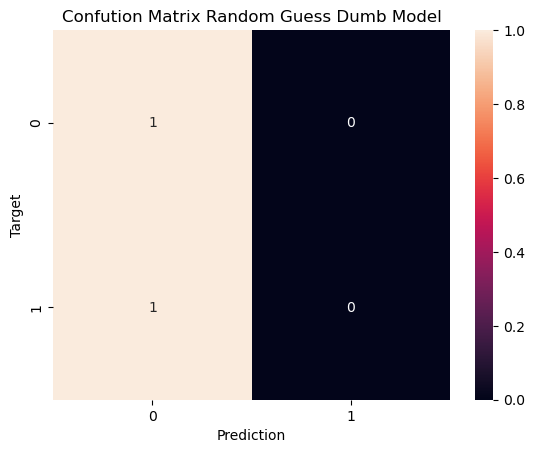

In [44]:

accuracy = accuracy_score(dumb_model2,test_target)*100
print(f'Accuracy : {accuracy:.2f}%')

cf = confusion_matrix(test_target, dumb_model2, normalize='true')
plt.figure()
sns.heatmap(cf, annot=True)
plt.xlabel('Prediction')
plt.ylabel('Target')
plt.title("Confution Matrix Random Guess Dumb Model")

In [81]:
new_input ={
    'Date':'2021-06-19',
    'Location':'Tuggerranong',
    'MinTemp':23.5,
    'MaxTemp':33.2,
    'Rainfall':10.2,
    'Evaporation':4.2,
    'Sunshine':np.nan,
    'WindGustDir':'NNW',
    'WindGustSpeed':52.0,
    'WindDir9am':'NW',
    'WindDir3pm':'NNE',
    'WindSpeed9am':13.0,
    'WindSpeed3pm':20.0,
    'Humidity9am':89.0,
    'Humidity3pm':58.0,
    'Pressure9am':1004.8,
    'Pressure3pm':1001.5,
    'Cloud9am':8.0,
    'Cloud3pm':5.0,
    'Temp9am':25.7,
    'Temp3pm':23.0,
    'RainToday':'Yes'
}

In [45]:
new_input_df = pd.DataFrame([new_input])

In [46]:
new_input_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,2021-06-19,Launceston,23.5,33.2,10.2,4.2,NaN,NNW,52.0,NW,...,20.0,89.0,58.0,1004.8,1001.5,8.0,5.0,25.7,33.0,Yes


In [47]:
new_input_df[numeric_col]=imputer.transform(new_input_df[numeric_col])
new_input_df[numeric_col]=scaler.transform(new_input_df[numeric_col])
new_input_df[encoded_col]=encoder.transform(new_input_df[categorical_col])

C:\Users\taush\AppData\Local\Temp\ipykernel_8400\71596979.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_input_df[encoded_col]=encoder.transform(new_input_df[categorical_col])
C:\Users\taush\AppData\Local\Temp\ipykernel_8400\71596979.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_input_df[encoded_col]=encoder.transform(new_input_df[categorical_col])
C:\Users\taush\AppData\Local\Temp\ipykernel_8400\71596979.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.in

In [48]:
new_input_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes
0,2021-06-19,Launceston,0.754717,0.714559,0.027493,0.050971,0.533566,NNW,0.356589,NW,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [49]:
x_new_input = new_input_df[numeric_col + encoded_col]
x_new_input

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes
0,0.754717,0.714559,0.027493,0.050971,0.533566,0.356589,0.149425,0.229885,0.89,0.58,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [54]:
prediction=model.predict(x_new_input)

In [55]:
prediction

array(['Yes'], dtype=object)

In [56]:
model.predict_proba(x_new_input)

array([[0.35333576, 0.64666424]])

In [59]:
[list(model.classes_).index(prediction)]

[1]

In [77]:
def predict_input(single_input):
    input_df=pd.DataFrame([single_input])
    input_df[numeric_col]=imputer.transform(input_df[numeric_col])
    input_df[numeric_col]=scaler.transform(input_df[numeric_col])
    input_df[encoded_col]=encoder.transform(input_df[categorical_col])
    x_input =input_df[numeric_col+encoded_col]
    pred = model.predict(x_input)[0]
    prob = model.predict_proba(x_input)[0][list(model.classes_).index(pred)]
    return print(f'Probility of Raining Tomorrow is:"{pred}" and Accuracy is: {(prob)*100:.2f}%')

In [82]:
predict_input(new_input)

Probility of Raining Tomorrow is:"Yes" and Accuracy is: 61.71%


C:\Users\taush\AppData\Local\Temp\ipykernel_8400\2349597421.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[encoded_col]=encoder.transform(input_df[categorical_col])
C:\Users\taush\AppData\Local\Temp\ipykernel_8400\2349597421.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_df[encoded_col]=encoder.transform(input_df[categorical_col])
C:\Users\taush\AppData\Local\Temp\ipykernel_8400\2349597421.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many

In [83]:
import joblib

In [86]:
aussie_rain={
    'model':model,
    'imputer':imputer,
    'scaler':scaler,
    'encoder':encoder,
    'input_col':input_col,
    'target_col':target_col,
    'numeric_col':numeric_col,
    'catagorical_col':categorical_col,
    'encoded_col':encoded_col
}

In [88]:
joblib.dump(aussie_rain,'aussie_rain.joblib')

['aussie_rain.joblib']

In [89]:
aussie_rain2= joblib.load('aussie_rain.joblib')

In [91]:
aussie_rain2['model'].coef_

array([[ 9.30806105e-01, -2.94915912e+00,  3.16391366e+00,
         6.41957834e-01, -1.64796054e+00,  6.82154655e+00,
        -6.98051388e-01, -1.45303292e+00,  3.29573960e-01,
         5.99816548e+00,  5.60338574e+00, -9.03420383e+00,
        -1.65363164e-01,  1.28376625e+00,  4.75512652e-01,
         2.01431079e+00,  5.95182273e-01, -5.60371723e-01,
         4.72499032e-01,  4.24402785e-03,  3.37599235e-01,
        -3.55575698e-01,  1.77137277e-01,  4.29677008e-01,
        -1.57583345e-02,  2.64458836e-02,  2.60996409e-01,
        -2.29350099e-02, -4.26160506e-02, -4.86887067e-01,
        -1.37524979e-01, -5.79314575e-01, -7.56150969e-01,
        -2.66373924e-01, -3.28180746e-01, -5.67919482e-01,
         7.93916941e-02,  9.70874231e-03,  6.65116245e-02,
        -9.50243894e-01, -4.55048058e-01,  8.28937643e-04,
        -4.67042633e-01, -4.67216793e-01, -7.94807009e-02,
         2.10731119e-01,  4.43028634e-01,  6.05471509e-01,
         4.26812913e-01, -2.82282928e-02,  2.39739332e-0